In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from plotly.matplotlylib.mplexporter.renderers import fig_to_vega
from statsmodels.tsa.stattools import zivot_andrews, adfuller
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [24]:
np.random.seed(42)
n = 120
break_point = 60

In [27]:
# Generate a series with a known mean shift
# First 60 observations centered at 50, next 60 centered at 80
series = np.concatenate([
    50 + np.random.normal(loc=0, scale=3, size=break_point),    # regime 1: mean = 50
    80 +  np.random.normal(loc=0, scale=3, size = break_point)  # regime 2: mean = 80
])

In [29]:
dates = pd.date_range("2022-01-01", freq="D", periods=n)
ts = pd.Series(series, index=dates)

In [32]:
ts

2022-01-01    52.373096
2022-01-02    47.271838
2022-01-03    54.208383
2022-01-04    45.794447
2022-01-05    51.760571
                ...    
2022-04-26    81.901757
2022-04-27    73.924572
2022-04-28    80.559363
2022-04-29    78.014641
2022-04-30    82.557300
Freq: D, Length: 120, dtype: float64

# Step 1: Visual Check

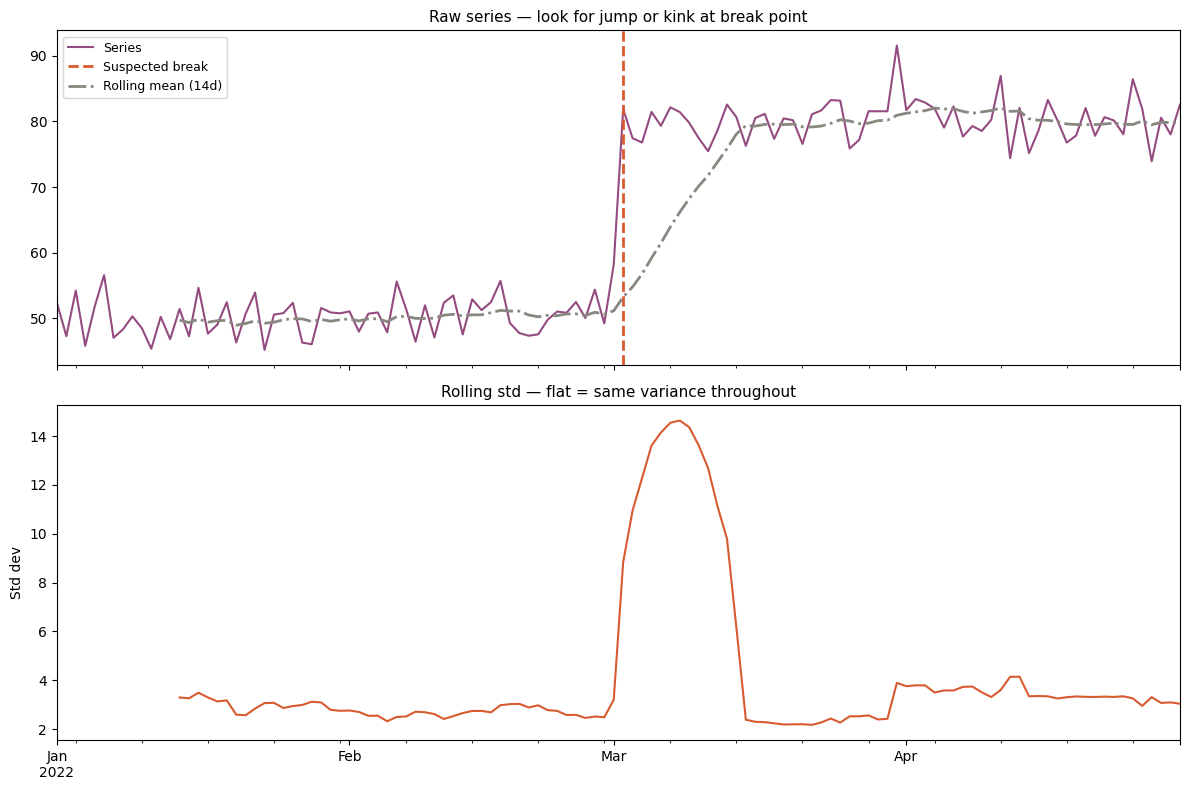

In [36]:
# Always plot first. A clear jump is immediately obvious
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top panel - the raw series
ts.plot(ax=axes[0], color="#944B80", linewidth=1.5, label="Series")

# axvline draws a vertical line at specific x position
# This marks where we suspect the break occurred
axes[0].axvline(dates[break_point], color="#D85A30", linewidth=2, linestyle="--", label="Suspected break")

# Rolling mean: If flat before and after but at different levels = mean shift
ts.rolling(14).mean().plot(ax=axes[0], color='#888780',
                            linewidth=2, linestyle='-.', label='Rolling mean (14d)')
axes[0].set_title('Raw series — look for jump or kink at break point', fontsize=11)
axes[0].legend(fontsize=9)

# Bottom panel — rolling standard deviation
# A jump here means variance shift (not just mean shift)
ts.rolling(14).std().plot(ax=axes[1], color='#D85A30', linewidth=1.5)
axes[1].set_title('Rolling std — flat = same variance throughout', fontsize=11)
axes[1].set_ylabel('Std dev')

plt.tight_layout()
plt.savefig('structural_break_visual.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 2: Chow test - Known Breakpoint

In [37]:
before = series[:break_point]   # First 60 values
after = series[break_point:]    # Last 60 values

In [38]:
# stats.ttest_ind performs an independent samples t-test
# It asks: could these two groups plausibly have the same mean?
# H0: means are equal (no break)
# H1: means are different (break confirmed)
t_stat, p_value = stats.ttest_ind(before, after)

In [40]:
print(f"Chow test (t-test for mean equality):")
print(f"Mean before : {before.mean():.2f}")
print(f"Mean after  : {after.mean():.2f}")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.6f}")

Chow test (t-test for mean equality):
Mean before : 50.28
Mean after  : 80.17
t-statistic : -53.6977
p-value     : 0.000000


In [43]:
# p < 0.05 means reject H0 — means are significantly different — break confirmed
if p_value < 0.05:
    print(f"Structural break CONFIRMED at t={break_point} (p < 0.05)")
else:
    print(f" No significant break detected at this point")


Structural break CONFIRMED at t=60 (p < 0.05)


# Step 3: Zivot Andrews test - Unknown Breakpoint

In [44]:
result = zivot_andrews(series, trim=0.15)
# trim=0.15 means ignore the first and last 15% of the series when scanning
# This prevents edge effects from being flagged as breaks
# The test needs enough data on both sides of any break to be reliable

In [45]:
za_stat = result[0]    # test statistic
za_p = result[1]    # p-value
za_crits = result[2]    # critical values dict
za_base_power = result[3]    # base power of the test
za_break_idx  = result[4]    # estimated break location (index)

In [46]:
print(f"Zivot-Andrews test:")
print(f"  ZA statistic  : {za_stat:.4f}")
print(f"  p-value       : {za_p:.4f}")
print(f"  Critical values: {za_crits}")
print(f"  Estimated break at index: {za_break_idx}")
print(f"  Estimated break date    : {dates[za_break_idx].date()}")

Zivot-Andrews test:
  ZA statistic  : -11.3272
  p-value       : 0.0000
  Critical values: {'1%': np.float64(-5.27644), '5%': np.float64(-4.81067), '10%': np.float64(-4.56618)}
  Estimated break at index: 59
  Estimated break date    : 2022-03-01


In [48]:
if za_p < 0.05:
    print(f"Structural break DETECTED at index {za_break_idx}")
else:
    print(f"No structural break detected")

Structural break DETECTED at index 59


# Handle the Break

### Option 1: Discard pre-break data

In [49]:
post_break = ts.iloc[break_point:]
print(f"Post-break series: {len(post_break)} observations")
print(f"Post-break mean  : {post_break.mean():.2f}")

Post-break series: 60 observations
Post-break mean  : 80.17


In [50]:
# ADF on post-break only — should now be stationary
adf_p = adfuller(post_break)[1]
print(f"ADF p-value (post-break): {adf_p:.4f}")
# If p < 0.05 → stationary within this regime ✓

ADF p-value (post-break): 0.0000


### Option 2: Dummy variable (for ML models)

In [51]:
# Create a binary column: 0 before break, 1 after break
df_model = pd.DataFrame({'value': series, 'date': dates})
df_model['post_break'] = (df_model.index >= break_point).astype(int)
# post_break = 0 means "we are in the old regime"
# post_break = 1 means "we are in the new regime"
# The ML model learns to add/subtract ~30 units when post_break=1
print(f"\nDummy variable approach:")
print(df_model[['value','post_break']].head(65).tail(10))
# You would then include 'post_break' as a feature in your model


Dummy variable approach:
        value  post_break
55  52.481550           0
56  50.039006           0
57  54.360602           0
58  49.206030           0
59  58.160507           0
60  81.877002           1
61  77.428527           1
62  76.787323           1
63  81.447417           1
64  79.329612           1


### Option 3: Separate models

In [52]:
mean_before = series[:break_point].mean()
mean_after  = series[break_point:].mean()
print(f"\nSeparate regime means:")
print(f"  Before break: {mean_before:.2f}")
print(f"  After break : {mean_after:.2f}")
print(f"  Shift       : +{mean_after - mean_before:.2f}")


Separate regime means:
  Before break: 50.28
  After break : 80.17
  Shift       : +29.89


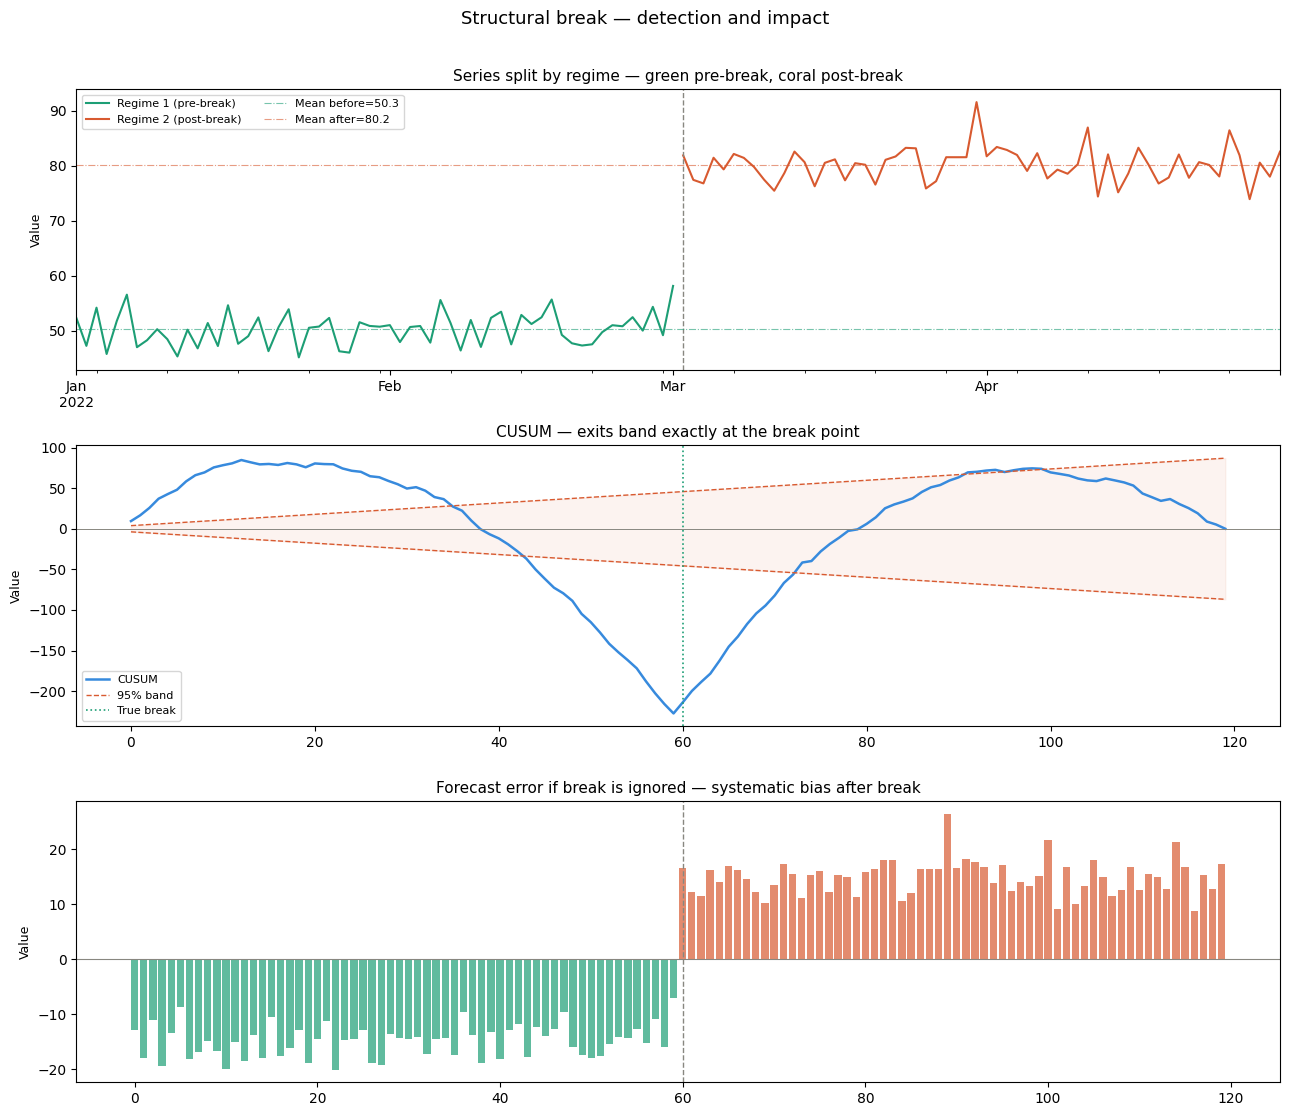

In [53]:
# ── Step 6: Full diagnostic plot ───────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=False)

# Panel 1 — original series split by regime
ts.iloc[:break_point].plot(ax=axes[0], color='#1D9E75',
                            linewidth=1.5, label='Regime 1 (pre-break)')
ts.iloc[break_point:].plot(ax=axes[0], color='#D85A30',
                            linewidth=1.5, label='Regime 2 (post-break)')
axes[0].axvline(dates[break_point], color='#888780',
                linewidth=1, linestyle='--')
axes[0].axhline(mean_before, color='#1D9E75', linewidth=0.8,
                linestyle='-.', alpha=0.6, label=f'Mean before={mean_before:.1f}')
axes[0].axhline(mean_after, color='#D85A30', linewidth=0.8,
                linestyle='-.', alpha=0.6, label=f'Mean after={mean_after:.1f}')
axes[0].set_title('Series split by regime — green pre-break, coral post-break', fontsize=11)
axes[0].legend(fontsize=8, ncol=2)

# Panel 2 — CUSUM (same as above, condensed)
axes[1].plot(cusum, color='#378ADD', linewidth=1.8, label='CUSUM')
axes[1].plot(upper, color='#D85A30', linestyle='--', linewidth=1, label='95% band')
axes[1].plot(lower, color='#D85A30', linestyle='--', linewidth=1)
axes[1].fill_between(range(n), lower, upper, alpha=0.07, color='#D85A30')
axes[1].axvline(break_point, color='#1D9E75', linewidth=1.2, linestyle=':', label='True break')
axes[1].axhline(0, color='#888780', linewidth=0.7)
axes[1].set_title('CUSUM — exits band exactly at the break point', fontsize=11)
axes[1].legend(fontsize=8)

# Panel 3 — forecast error if break ignored
# Simulate: model trained on full data, predicts a flat mean
naive_fc    = np.repeat(series.mean(), n)    # whole-series mean as forecast
naive_error = series - naive_fc              # error = actual - predicted

axes[2].bar(range(n), naive_error,
            color=['#D85A30' if i >= break_point else '#1D9E75' for i in range(n)],
            alpha=0.7)
axes[2].axhline(0, color='#888780', linewidth=0.8)
axes[2].axvline(break_point, color='#888780', linewidth=1, linestyle='--')
axes[2].set_title('Forecast error if break is ignored — systematic bias after break', fontsize=11)
axes[2].set_ylabel('Error')

for ax in axes:
    ax.set_ylabel('Value', fontsize=9)

plt.suptitle('Structural break — detection and impact', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('structural_break_full.png', dpi=150, bbox_inches='tight')
plt.show()